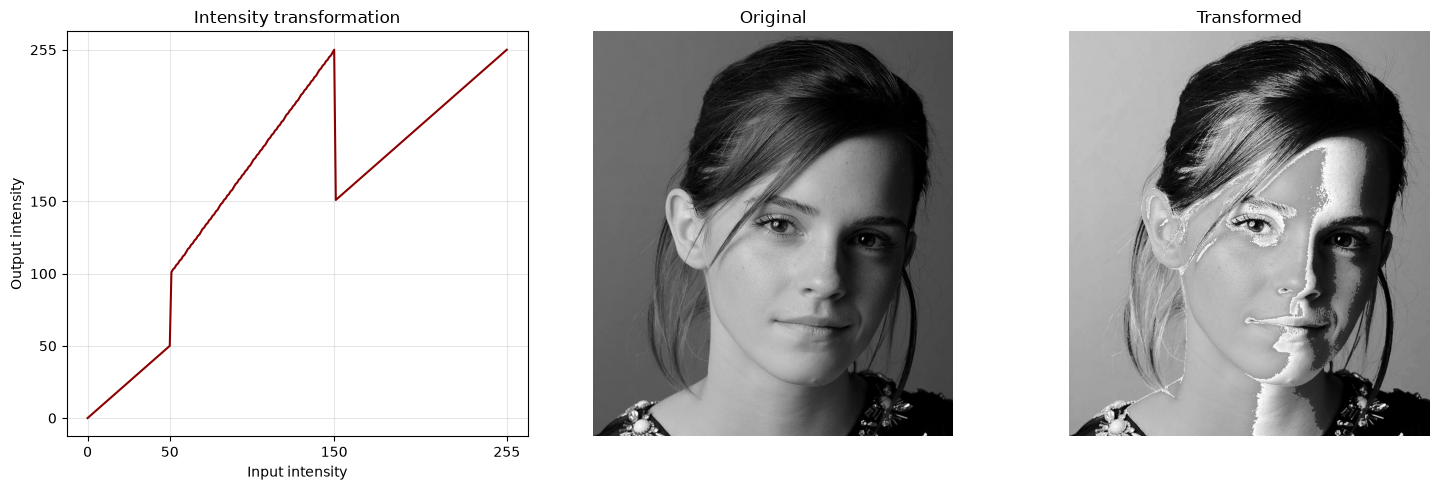

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
  x = breakpoints[:,0].astype(int)
  y = breakpoints[:,1].astype(int)

  c1 = np.linspace(y[0], y[1], x[1]-x[0]+1)
  c2 = np.linspace(y[2], y[3], x[3]-x[2]+1)
  c3 = np.linspace(y[4], y[5], x[5]-x[4]+1)

  piecewise_func = np.concatenate((c1, c2[1:], c3[1:]), axis=0)

  lut = np.clip(piecewise_func, 0, 255).astype(np.uint8)
  transformed = cv.LUT(im, lut)
  return transformed, lut


im = cv.imread(r'D:\Image processing and Computer Vision\Images\emma.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255,255]
], dtype=np.float32)

transformed, lut = intensity_transform(im, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), lut, color="darkred")
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Intensity transformation")
axes[0].set_xticks(sorted(set(breakpoints[:,0].astype(int))))
axes[0].set_yticks(sorted(set(breakpoints[:,1].astype(int))))
axes[0].grid(alpha=0.3)

axes[1].imshow(im, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Original")
axes[1].axis("off")

axes[2].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Transformed")
axes[2].axis("off")

plt.tight_layout()
plt.show()